In [27]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import time
import sys

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, SimpleRNN

# Network Parameters
HIDDEN_SIZE = 30
INPUT_LENGTH = 10

LR = 0.001
STEP_EPOCHS = 25
N_EPOCHS = 50
BATCH_SIZE = 32
BUFFER_SIZE = 10000

VERBOSE = True


In [28]:

# Training parameters
I_SERIES = 0 	# 0 - 5,000 training samples
	            # 1 - 50,000 training samples
TEST = True


In [29]:

#%% Network definition

class RNN_Net(Model):

    def __init__(self, input_dim, hidden_dim, batch_size, output_dim=1,
                 num_layers=1):
        super(RNN_Net, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.batch_size = batch_size
        self.output_dim = output_dim
        self.num_layers = num_layers

        # if self.num_layers>1:
        self.rnn_in = SimpleRNN(
                units = self.hidden_dim,
                activation='relu',
                kernel_initializer='glorot_normal',
                #input_shape=self.input_dim
                )

        self.linear = Dense(self.output_dim, activation='linear')

    def call(self, x):
        out_rnn = self.rnn_in(x)
        output = self.linear(out_rnn)
        return output


In [30]:

#%% Training and testing function

def _validation_loss():
    validation_loss = 0
    for batch, (x,y) in enumerate(val_ds):

        y_pred = net(x)
        loss_value = loss(y,y_pred)

        validation_loss = validation_loss + tf.math.reduce_mean(loss_value)

    return validation_loss/validation_steps

def predict(X,Y):
    # i_test = 0
    total_test_loss = np.ndarray((n_test,), dtype='float')

    t_start = time.time()
    # breakpoint()
    x_pr = X[0]
    for i_pred in range(n_test):#int(T/t_step-p)):#
        x_pred = x_pr[i_pred:p+i_pred].reshape((1,p,3))
        y_pred = net.predict(x_pred, batch_size=32, verbose = 0)
        test_loss = loss(y_pred,Y[i_pred])
        total_test_loss[i_pred] = test_loss.numpy()
        x_pr = np.concatenate((x_pr,y_pred),0)

    t_end = time.time()

    print('Elapsed time: '+str(t_end-t_start)+' s')

    return x_pr.T, total_test_loss


In [31]:

#%% Data pre-processing
def preprocess_data_recurrent(i_ser,p):

    t_series = np.load(f'series_{i_ser:04d}.npz')['tseries']
    time_series = t_series
    T = time_series.shape[1]
    processed_features = np.ndarray((T-p,p,3),float)
    output_targets = np.ndarray((T-p,3),float)

    for i_p in range(0,T-p):
        for i_coeff in range(3):

            processed_features[i_p,:,i_coeff] = time_series[i_coeff,i_p:i_p+p]
            output_targets[i_p,i_coeff] = time_series[i_coeff,i_p+p] # Stores next 'p' samples for a given i_p

    return processed_features, output_targets


In [32]:

#%% Main
if __name__ == '__main__':
    #load data
    p = INPUT_LENGTH
    verbose = VERBOSE

    epochs = N_EPOCHS
    # checkpoint_freq =

    X, Y =  preprocess_data_recurrent(I_SERIES,p)

    n_train = int(10**np.floor(np.log10(X.shape[0]))/2)
    n_val = n_train
    n_test = X.shape[0] - n_train*2

    steps_per_epoch = int(np.ceil(n_train/BATCH_SIZE))
    validation_steps = int(np.ceil(n_val/BATCH_SIZE))

    train_ds = tf.data.Dataset.from_tensor_slices(
    (X[:n_train], Y[:n_train]))
    train_ds = train_ds.shuffle(BUFFER_SIZE)
    train_ds = train_ds.batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices(
        (X[n_train:n_train+n_val],
         Y[n_train:n_train+n_val]))
    val_ds = val_ds.batch(BATCH_SIZE)

    X_test = X[-n_test:]
    Y_test = Y[-n_test:]

    #build the model
    net = RNN_Net((p,3), HIDDEN_SIZE, batch_size = BATCH_SIZE,
                  output_dim = 3, num_layers = 1)


    loss = tf.keras.losses.MeanSquaredError()
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                LR,
                decay_steps=int(steps_per_epoch*STEP_EPOCHS),
                decay_rate=0.5,
                staircase=True)
    # lr_schedule = LR

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    #%% Model training
    history_train_loss = list()
    history_val_loss = list()

    for epoch in range(N_EPOCHS):
        if VERBOSE == 0:
            t_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)
            v_loss = tf.keras.metrics.Mean('validation_loss', dtype=tf.float32)
            t_start = time.time()
        else:
            t_loss = 0
            progbar = tf.keras.utils.Progbar(steps_per_epoch, stateful_metrics=["train loss"])
        print(f'%% Epoch:{epoch+1:d}/{N_EPOCHS:d}')

        for batch, (x, y) in enumerate(train_ds.take(steps_per_epoch)):
            y = tf.squeeze(y)
            with tf.GradientTape() as tape:
                y_pred = net(x)
                loss_value = loss(y, y_pred)
            grads = tape.gradient(loss_value, net.variables)
            optimizer.apply_gradients(zip(grads, net.variables))

            if VERBOSE == 0:
                t_loss.update_state(loss_value)
            else:
                t_loss += loss_value
                progbar.add(1, values=[("train loss", loss_value)])

        # End of epoch
        if VERBOSE == 0:
            t_end = time.time()
            v_loss.update_state(_validation_loss())
            print(f"{t_end-t_start:.2f} s - training loss: {t_loss.result():.4e} - validation loss: {v_loss.result():.4e}", flush=True)
            history_train_loss.append(t_loss.result().numpy())
            history_val_loss.append(v_loss.result().numpy())
        else:
            t_loss /= steps_per_epoch
            history_train_loss.append(t_loss.numpy())
            t_loss = 0
            v_loss = _validation_loss()
            print(f"validation loss: {v_loss:.4e}")
            history_val_loss.append(v_loss.numpy())


    # fig = plt.figure()
    # ax = fig.add_subplot(1)
    # ax.plot(history_train_loss, label='Training')
    # ax.plot(history_val_loss, label='Validation')
    # ax.legend()
    # ax.set(xlabel='$Epoch$', ylabel='$Loss$',yscale='log')
    # plt.savefig('Loss_LR_005', format=png)
    # plt.show()
    # if TEST == False:
    #     sys.exit(0)



%% Epoch:1/50
  4/157 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - train loss: 210.6883 

C:\Users\ilias\AppData\Roaming\Python\Python312\site-packages\keras\src\optimizers\base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['seed_generator_2/seed_generator_state'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - train loss: 2.0763
validation loss: 4.3233e+00
%% Epoch:2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - train loss: 0.7387
validation loss: 1.3221e+00
%% Epoch:3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - train loss: 0.8583
validation loss: 8.0541e-01
%% Epoch:4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - train loss: 0.2271
validation loss: 5.6314e-01
%% Epoch:5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - train loss: 0.6480
validation loss: 4.5649e-01
%% Epoch:6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - train loss: 0.5137
validation loss: 3.5777e-01
%% Epoch:7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - train loss: 0.1833
validation loss: 2.8238e-01
%% Epoch:8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - train loss: 0.0658
validation loss: 2.3393e-01
%% Epoch:9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - train loss: 0.2317
validation loss: 2.0599e-01
%% Epoch:10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/ste

In [34]:
X_pred, test_loss = predict(X_test,Y_test)

Elapsed time: 590.6486704349518 s


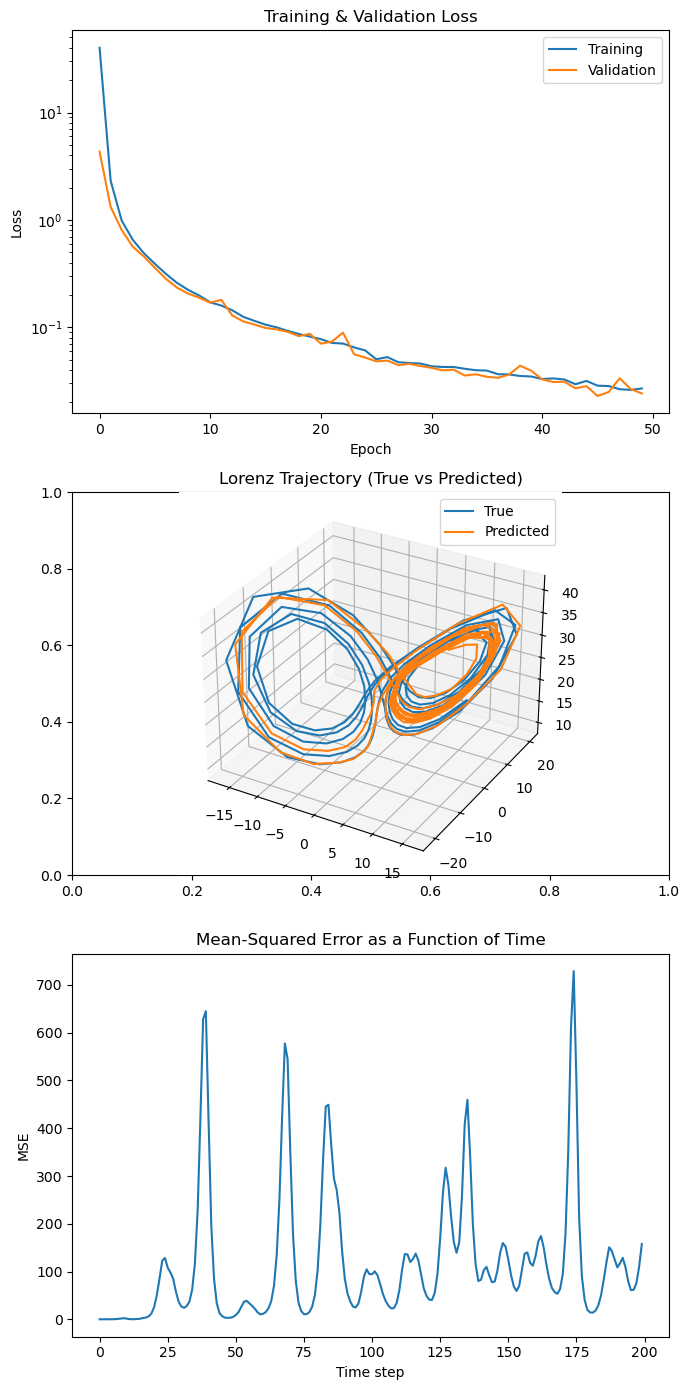

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(7, 14))  # 3 rows, 1 column

# --- (1) Training & validation loss ---
ax = axes[0]
ax.plot(history_train_loss, label='Training')
ax.plot(history_val_loss, label='Validation')
ax.legend()
ax.set(xlabel='Epoch', ylabel='Loss', yscale='log', title='Training & Validation Loss')

# --- (2) 3D trajectory plot ---
ax = fig.add_subplot(3, 1, 2, projection='3d')  
ax.plot(X_test[:200, 0, 0], X_test[:200, 0, 1], X_test[:200, 0, 2], label='True')
ax.plot(X_pred[0, :200], X_pred[1, :200], X_pred[2, :200], label='Predicted')
ax.set(title='Lorenz Trajectory (True vs Predicted)')
ax.legend()

# --- (3) MSE over time ---
ax = axes[2]
ax.plot(test_loss[:200])
ax.set(title='Mean-Squared Error as a Function of Time', xlabel='Time step', ylabel='MSE')

plt.tight_layout()
plt.savefig('RNNs_LR_decay.png', dpi=300)
plt.show()